In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

/tmp/ipykernel_4864/3609252841.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.drop("customerID", axis=1, inplace=True)

In [6]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [7]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [8]:
df.select_dtypes(include='object').columns

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod'],
      dtype='object')

In [9]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [10]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [11]:
df.shape

(7043, 31)

In [12]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [13]:
numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

df[numerical_cols].head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


**StandardScaler**

In [14]:
df_standard = df.copy()

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standard[numerical_cols] = scaler.fit_transform(
    df_standard[numerical_cols]
)

In [16]:
df_standard[numerical_cols].head()

,tenure,MonthlyCharges,TotalCharges
0,-1.277445,-1.160323,-0.994242
1,0.066327,-0.259629,-0.173244
2,-1.236724,-0.362660,-0.959674
3,0.514251,-0.746535,-0.194766
4,-1.236724,0.197365,-0.940470


In [17]:
df_standard[numerical_cols].mean()

,0
tenure,-2.421273e-17
MonthlyCharges,-6.406285e-17
TotalCharges,-1.488074e-17


In [18]:
df_standard[numerical_cols].std()

,0
tenure,1.000071
MonthlyCharges,1.000071
TotalCharges,1.000071


StandardScaler was applied to numerical features. It standardizes the data by transforming features to have a mean of 0 and a standard deviation of 1. This is beneficial for algorithms such as SVM, Logistic Regression, and SVR.

**MINMAXScaler**

In [19]:
df_minmax = df.copy()

In [20]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

df_minmax[numerical_cols] = minmax.fit_transform(
    df_minmax[numerical_cols]
)

In [21]:
df_minmax[numerical_cols].head()

,tenure,MonthlyCharges,TotalCharges
0,0.013889,0.115423,0.001275
1,0.472222,0.385075,0.215867
2,0.027778,0.354229,0.010310
3,0.625000,0.239303,0.210241
4,0.027778,0.521891,0.015330


In [22]:
df_minmax[numerical_cols].min()

,0
tenure,0.0
MonthlyCharges,0.0
TotalCharges,0.0


In [23]:
df_minmax[numerical_cols].max()

,0
tenure,1.0
MonthlyCharges,1.0
TotalCharges,1.0


MinMaxScaler was applied to transform numerical features into a fixed range between 0 and 1. This scaling technique is useful for distance-based algorithms such as KNN and helps ensure all features contribute equally during model training.

Comparing the StandardScaler and MinMAx Scaler


In [24]:
print("Original")
print(df[numerical_cols].head())

print("\nStandardScaler")
print(df_standard[numerical_cols].head())

print("\nMinMaxScaler")
print(df_minmax[numerical_cols].head())

Original
   tenure  MonthlyCharges  TotalCharges
0       1           29.85         29.85
1      34           56.95       1889.50
2       2           53.85        108.15
3      45           42.30       1840.75
4       2           70.70        151.65

StandardScaler
     tenure  MonthlyCharges  TotalCharges
0 -1.277445       -1.160323     -0.994242
1  0.066327       -0.259629     -0.173244
2 -1.236724       -0.362660     -0.959674
3  0.514251       -0.746535     -0.194766
4 -1.236724        0.197365     -0.940470

MinMaxScaler
     tenure  MonthlyCharges  TotalCharges
0  0.013889        0.115423      0.001275
1  0.472222        0.385075      0.215867
2  0.027778        0.354229      0.010310
3  0.625000        0.239303      0.210241
4  0.027778        0.521891      0.015330


**FEATURE** **ENGINEERING**

1. AvgMonthlySpend

In [25]:
df["AvgMonthlySpend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

In [26]:
df[["tenure","TotalCharges","AvgMonthlySpend"]].head()

,tenure,TotalCharges,AvgMonthlySpend
0,1,29.85,14.925000
1,34,1889.50,53.985714
2,2,108.15,36.050000
3,45,1840.75,40.016304
4,2,151.65,50.550000


2. ServiceCount

In [27]:
service_cols = [
    'PhoneService',
    'MultipleLines_No phone service',
    'MultipleLines_Yes',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

In [28]:
df["ServiceCount"] = df[service_cols].sum(axis=1)

In [29]:
df[["ServiceCount"]].head()

,ServiceCount
0,2
1,3
2,3
3,4
4,1


3. IsLongTermCustomer

In [30]:
df["IsLongTermCustomer"] = (
    df["tenure"] > 24
).astype(int)

In [31]:
df[["tenure","IsLongTermCustomer"]].head()

,tenure,IsLongTermCustomer
0,1,0
1,34,1
2,2,0
3,45,1
4,2,0


In [32]:
df[[
    "AvgMonthlySpend",
    "ServiceCount",
    "IsLongTermCustomer"
]].head()

,AvgMonthlySpend,ServiceCount,IsLongTermCustomer
0,14.925000,2,0
1,53.985714,3,1
2,36.050000,3,0
3,40.016304,4,1
4,50.550000,1,0


**FEATURE SELECTION**

1. CORRELATION WITH CHURN

In [33]:
corr_with_churn = df.corr()['Churn'].sort_values(
    ascending=False
)

corr_with_churn

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
MonthlyCharges,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102
AvgMonthlySpend,0.014873


In [34]:
top_corr = corr_with_churn.head(10)

print(top_corr)

Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
AvgMonthlySpend                   0.014873
Name: Churn, dtype: float64


2. RANDOM FOREST FEATURE IMPORTANCE

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [37]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [38]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,TotalCharges,0.145139
4,tenure,0.134552
7,MonthlyCharges,0.131480
30,AvgMonthlySpend,0.129045
28,PaymentMethod_Electronic check,0.034952
11,InternetService_Fiber optic,0.034813
31,ServiceCount,0.034541
32,IsLongTermCustomer,0.031696
26,Contract_Two year,0.025247
0,gender,0.023280


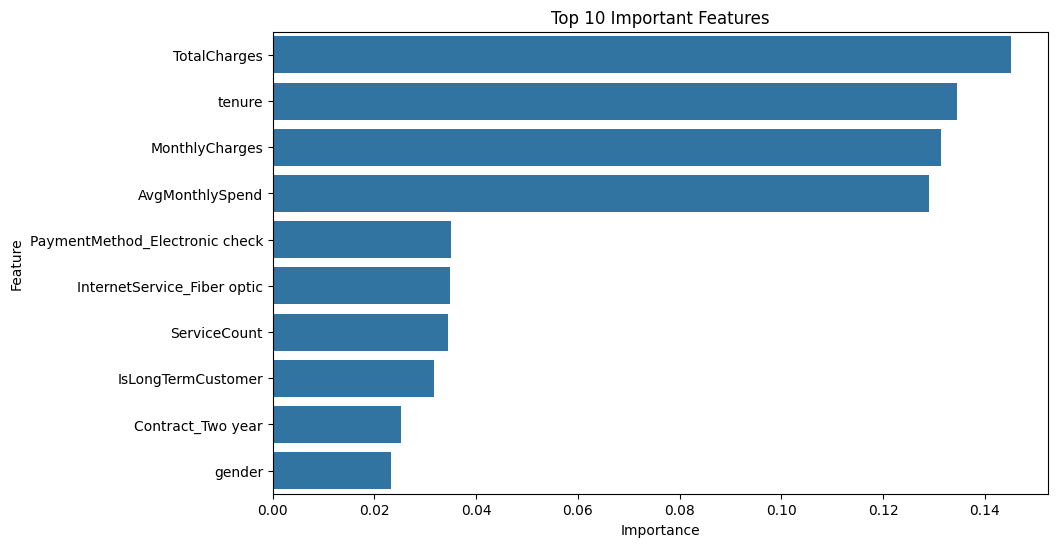

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Important Features'
)

plt.show()

Feature selection was performed using correlation analysis and Random Forest feature importance. Features such as tenure, TotalCharges, MonthlyCharges, Contract type, and ServiceCount showed strong predictive power for churn prediction.

**Feature Selection completed**

1. SMOTE (Synthetic Minority Oversampling Technique)

In [40]:
!pip install imbalanced-learn

In [41]:
from imblearn.over_sampling import SMOTE

In [42]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [43]:
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [44]:
smote = SMOTE(
    random_state=42
)

X_smote, y_smote = smote.fit_resample(
    X,
    y
)

In [45]:
print(y_smote.value_counts())

Churn
0    5174
1    5174
Name: count, dtype: int64


"SMOTE was applied to address class imbalance by generating synthetic samples for the minority churn class. This helps the model learn churn patterns more effectively and reduces bias toward the majority class."

2. CLASS WEIGHTS

In [46]:
class_weight='balanced'

We'll use this later during classification

**TRAIN / VALIDATION / TEST SPLIT**

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_smote,
    y_smote,
    test_size=0.30,
    random_state=42,
    stratify=y_smote
)

In [49]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [50]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (7243, 33)
Validation: (1552, 33)
Test: (1553, 33)
